<a href="https://colab.research.google.com/github/Sneha123-zudo/Natural-Language-Processing-NLP-/blob/main/Feature_Extraction_NLP_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Bag-of-words-tells the frequency of words**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
docs = ["i love nlp", "i love ml"]

In [ ]:
Vectorizer = CountVectorizer()
X = Vectorizer.fit_transform(docs)

In [ ]:
print(Vectorizer.get_feature_names_out())

['love' 'ml' 'nlp']


In [ ]:
print(X.toarray())

[[1 0 1]
 [1 1 0]]


**TF-IDF - Tells importance of the words uses weights**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

docs = ["i love nlp", "i love ml"]

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(docs)


In [ ]:
print(vectorizer.get_feature_names_out())
print(X.toarray())

['love' 'ml' 'nlp']
[[0.57973867 0.         0.81480247]
 [0.57973867 0.81480247 0.        ]]


**N - grams - same tells frequency but here it make the sets of words it can be 2 or more you need to specify N**

In [ ]:
vectorizer = CountVectorizer(ngram_range=(2,2))
X = vectorizer.fit_transform(["i love nlp", "i love ml"])

In [ ]:
print(vectorizer.get_feature_names_out())
print(X.toarray())

['love ml' 'love nlp']
[[0 1]
 [1 0]]


**Similarity Based Techniques**
1. Exact Match

In [ ]:
t1 = "i love nlp"
t2 = "i love nlp"
print(t1 == t2)

True


In [ ]:
t1 = "i love nlp"
t2 = "i love ml"
print(t1 == t2)


False


2. Jaccard Similarity

In [ ]:
def jaccard(a, b):
    a = set(a.split())
    b = set(b.split())
    return len(a & b) / len(a | b)

print(jaccard("i love nlp", "i love ml"))


0.5


3. N - gram overlap

In [ ]:
def ngrams(text, n):
    words = text.split()
    return [" ".join(words[i:i+n]) for i in range(len(words)-n+1)]

s1 = ngrams("i love nlp", 2)
s2 = ngrams("i love ml", 2)

common = set(s1) & set(s2)
score = len(common) / len(set(s1) | set(s2))
print(score)


0.3333333333333333


4. Edit Distance - How many edits (insert, delete, replace) to change one text into another.

In [ ]:
import nltk
nltk.download('punkt')
from nltk.metrics import edit_distance

print(edit_distance("cat", "cutter"))


4


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


5. Cosine Similarity

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

docs = ["i love nlp", "i love ml"]
vec = TfidfVectorizer()
X = vec.fit_transform(docs)

print(cosine_similarity(X[0], X[1]))


[[0.33609693]]


**Linguistic and syntactic Analysis**
1. POS Tagging

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng') # Added to address the LookupError

from nltk import word_tokenize, pos_tag

text = "I love learning NLP"
tokens = word_tokenize(text)
tags = pos_tag(tokens)
print(tags)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


[('I', 'PRP'), ('love', 'VBP'), ('learning', 'VBG'), ('NLP', 'NNP')]


2. Chunking (Shallow Parsing)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 4.6 MB/s eta 0:00:00


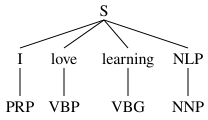

In [ ]:
!pip install svgling
grammar = "NP: {<DT>?<JJ>*<NN>}"
parser = nltk.RegexpParser(grammar)
tree = parser.parse(tags)
tree

3. Dependency Parsing

In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")

doc = nlp("She eats apples")
for token in doc:
    print(token.text, token.dep_, token.head.text)


She nsubj eats
eats ROOT eats
apples dobj eats


4. Constituency Parsing

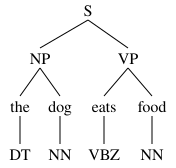

In [ ]:
sentence = "the dog eats food"
tokens = nltk.word_tokenize(sentence)
tags = nltk.pos_tag(tokens)

grammar = """
S: {<NP><VP>}
NP: {<DT><NN>}
VP: {<VBZ><NN>}
"""
parser = nltk.RegexpParser(grammar)
tree = parser.parse(tags)
tree


5. Named Entity Recognition

In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")
doc = nlp("Rahul works at Google in India")

for ent in doc.ents:
    print(ent.text, ent.label_)


Google ORG
India GPE


6. Morphological Analysis

In [ ]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
import nltk
nltk.download('wordnet') # Download the wordnet corpus

ps = PorterStemmer()
print(ps.stem("playing"))   # play

lem = WordNetLemmatizer()
print(lem.lemmatize("running", pos="v"))  # run

[nltk_data] Downloading package wordnet to /root/nltk_data...


play
run


**Semantic Based Techniques**
1. Word Sense Disambiguation (WSD)

In [ ]:
from nltk.corpus import wordnet

syns = wordnet.synsets("bank")
for s in syns[:3]:
    print(s.name(), "-", s.definition())


bank.n.01 - sloping land (especially the slope beside a body of water)
depository_financial_institution.n.01 - a financial institution that accepts deposits and channels the money into lending activities
bank.n.03 - a long ridge or pile


2. Semantic Similarity (Meaning-Based)

In [ ]:
import sys
if 'google.colab' in sys.modules:
  !pip install gensim
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity

sents = [["i","love","nlp"],["i","like","language"],["dog","barks"]]
model = Word2Vec(sents, vector_size=50, min_count=1)

v1 = model.wv["love"]
v2 = model.wv["like"]
v3 = model.wv["dog"]

print(cosine_similarity([v1],[v2]))  # high
print(cosine_similarity([v1],[v3]))  # low

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.2 MB/s eta 0:00:00
[[-0.0562143]]
[[0.08872983]]


**LDA (Latent Dirichlet Allocation)- used to find new topics**

In [ ]:
docs = [
    ["football","match","goal","team"],
    ["cricket","bat","ball","match"],
    ["python","code","programming"],
    ["java","software","development"]
]

In [ ]:
from gensim import corpora

dictionary = corpora.Dictionary(docs)
print(dictionary.token2id)


{'football': 0, 'goal': 1, 'match': 2, 'team': 3, 'ball': 4, 'bat': 5, 'cricket': 6, 'code': 7, 'programming': 8, 'python': 9, 'development': 10, 'java': 11, 'software': 12}


In [ ]:
corpus = [dictionary.doc2bow(doc) for doc in docs]
print(corpus)


[[(0, 1), (1, 1), (2, 1), (3, 1)], [(2, 1), (4, 1), (5, 1), (6, 1)], [(7, 1), (8, 1), (9, 1)], [(10, 1), (11, 1), (12, 1)]]


In [ ]:
from gensim.models import LdaModel

lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=2, passes=10)


In [ ]:
topics = lda.print_topics()
for t in topics:
    print(t)


(0, '0.119*"development" + 0.119*"java" + 0.119*"software" + 0.119*"programming" + 0.119*"code" + 0.119*"python" + 0.041*"cricket" + 0.041*"ball" + 0.041*"match" + 0.041*"bat"')
(1, '0.172*"match" + 0.103*"goal" + 0.103*"team" + 0.103*"football" + 0.103*"bat" + 0.103*"ball" + 0.103*"cricket" + 0.035*"python" + 0.035*"code" + 0.035*"programming"')


In [ ]:
for i, doc in enumerate(corpus):
    print(f"Doc {i}:", lda.get_document_topics(doc))


Doc 0: [(0, np.float32(0.10455925)), (1, np.float32(0.8954407))]
Doc 1: [(0, np.float32(0.10470843)), (1, np.float32(0.89529157))]
Doc 2: [(0, np.float32(0.87022966)), (1, np.float32(0.12977028))]
Doc 3: [(0, np.float32(0.8703432)), (1, np.float32(0.12965673))]


**Glove - word embeddings**

In [ ]:
import os

# Check if the file exists, if not, download it
if not os.path.exists("glove.6B.100d.txt"):
    print("Downloading glove.6B.100d.txt...")
    !wget http://nlp.stanford.edu/data/glove.6B.zip
    !unzip glove.6B.zip
    !rm glove.6B.zip # Clean up the zip file
    print("Download and extraction complete.")

embeddings = {}
with open("glove.6B.100d.txt", "r", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = list(map(float, values[1:]))
        embeddings[word] = vector


--2026-01-19 07:20:29--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-01-19 07:20:29--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-01-19 07:20:30--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

v1 = np.array(embeddings["king"]).reshape(1,-1)
v2 = np.array(embeddings["queen"]).reshape(1,-1)

print(cosine_similarity(v1, v2))


[[0.75076908]]


In [ ]:
king = np.array(embeddings["king"])
man = np.array(embeddings["man"])
woman = np.array(embeddings["woman"])

result = king - man + woman

# Find closest word
def closest_word(vec, embeddings):
    best_word, best_score = None, -1
    for w, v in embeddings.items():
        score = cosine_similarity([vec],[v])[0][0]
        if score > best_score:
            best_word, best_score = w, score
    return best_word

print(closest_word(result, embeddings))


king
